In [3]:
# run from workspace root or uncomment to add the parent directory to the python path:
# import sys
# sys.path.append("..")
import gymnasium as gym
import mo_gymnasium as mo_gym
import wandb
import numpy as np
import matplotlib.pyplot as plt

from morl_baselines.multi_policy.pareto_q_learning.pql import PQL
from wrappers import Convert2DStateWrapper, CombineWrapper, FearWrapper

from utils import visualize_front, visualize_front_general

c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Starting training (100000 timesteps)...


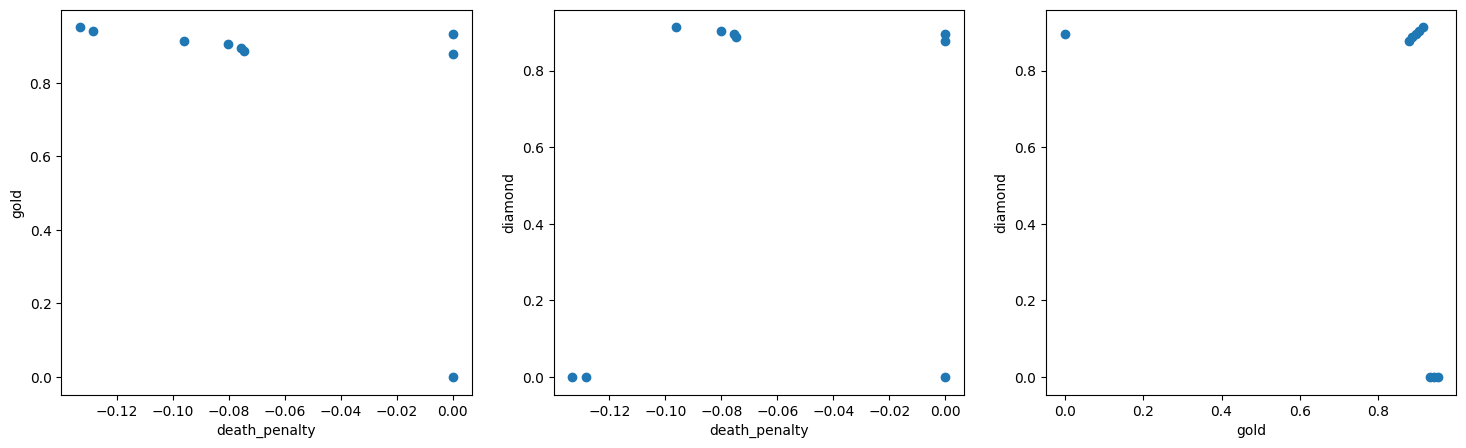

eval/cardinality,▁▁▁▁▁▁▁▁▁▁
eval/eum,█▁▁▁▁▁▁▁▁▁
eval/hypervolume,█▁▁▁▁▁▁▁▁▁
global_step,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇████
eval/cardinality,3
eval/eum,0.58743
eval/hypervolume,0.77004
global_step,100000


In [ ]:
env = mo_gym.make("resource-gathering-v0")
env = Convert2DStateWrapper(env)

ref_point = np.array([-1, 0, 0])
eval_env = Convert2DStateWrapper(mo_gym.make("resource-gathering-v0"))

TOTAL_TIMESTEPS = 100000

agent = PQL(
    env=env,
    ref_point=ref_point,
    gamma=0.99,
    initial_epsilon=1.0,
    epsilon_decay_steps=TOTAL_TIMESTEPS,
    final_epsilon=0.05,
    seed=42,
    log=True,
)

print(f"Starting training ({TOTAL_TIMESTEPS} timesteps)...")
pareto_front = agent.train(
    total_timesteps=TOTAL_TIMESTEPS,
    eval_env=eval_env,
    ref_point=ref_point,
    log_every=TOTAL_TIMESTEPS / 10,
    action_eval="hypervolume",
)

visualize_front(pareto_front)

wandb.finish()


In [ ]:
from morl_baselines.common.utils import make_gif

class EvalPQLWrapper():
    """
    Wrapper that allows the evaluation of a PQL agent.

    """
    def __init__(self, env, agent: PQL):
        self.env = env
        self.pql = agent

    def eval(self, state: int, weight: np.ndarray):
        """Return the action for a given state and weight over the objectives."""
        state = int(np.ravel_multi_index(state, self.env.unwrapped.map.shape))
        pcs = self.pql.get_local_pcs(state)
        pcs = np.array(list(pcs))
        # get the action that maximizes the weighted sum of the objectives
        action = np.argmax(np.sum(pcs * weight, axis=1))
        # choose a q 
        return action

env2 = Convert2DStateWrapper(mo_gym.make("resource-gathering-v0", render_mode='rgb_array'))

eval_agent = EvalPQLWrapper(env2, agent)

make_gif(env2, eval_agent, weight=np.array([0.9, 0.1, 0.0]), fps=10, fullpath="./experiments/gifs/pql_resource_gather_0.9_0.1_0.0")
make_gif(env2, eval_agent, weight=np.array([0.3, 0.7, 0.0]), fps=10, fullpath="./experiments/gifs/pql_resource_gather_0.3_0.7_0.0")
make_gif(env2, eval_agent, weight=np.array([0.0, 1.0, 0.0]), fps=10, fullpath="./experiments/gifs/pql_resource_gather_0.0_1.0_0.0")

c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


KeyError: 10

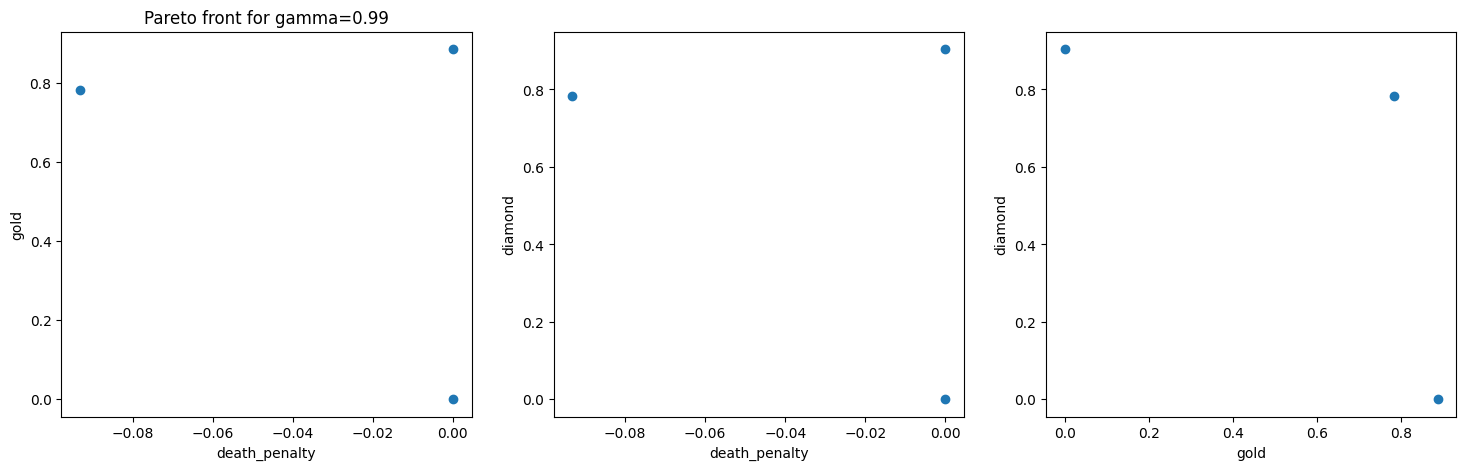

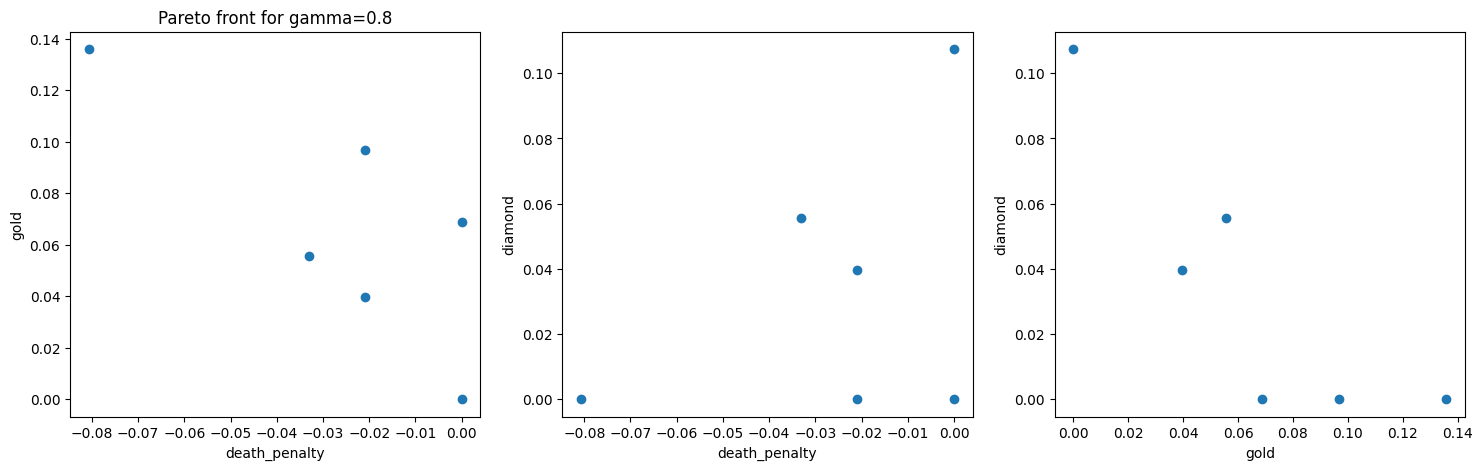

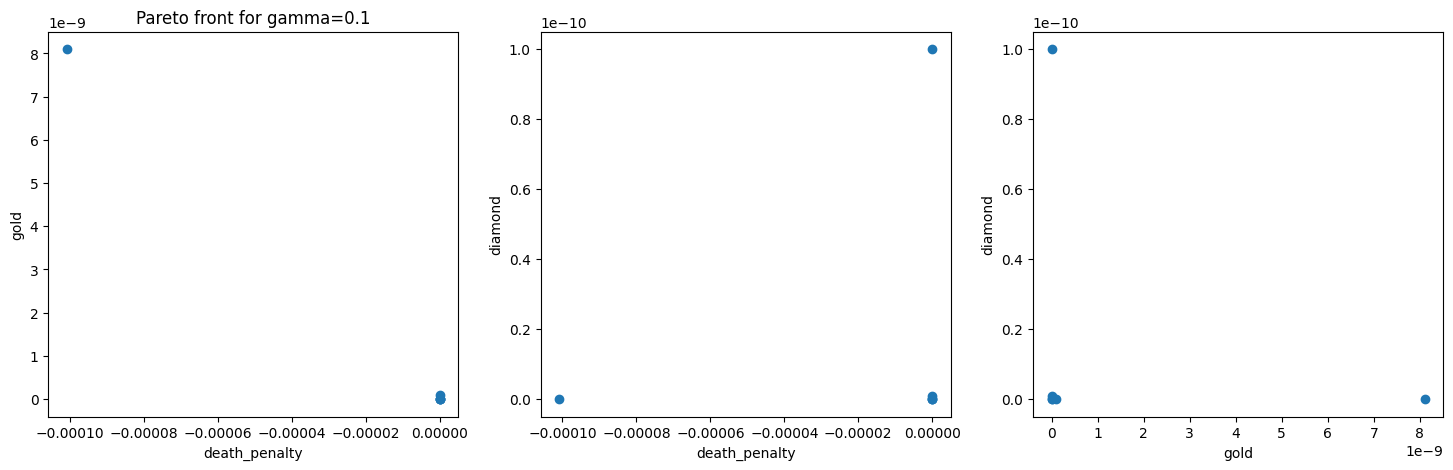

In [ ]:
env  = mo_gym.make("resource-gathering-v0")
env.unwrapped.pareto_front(gamma=0.99)

# gridplot with different gamma values
for gamma in [0.99, 0.8, 0.1]:
    # in one row: 3 plots with death/gold/diamond
    fig, axs = plt.subplots(1, 3)
    fig.set_figwidth(18)
    fig.set_figheight(5)
    pf = np.array(env.unwrapped.pareto_front(gamma=gamma))
    axs[0].scatter(pf[:, 0], pf[:, 1])
    axs[1].scatter(pf[:, 0], pf[:, 2])
    axs[2].scatter(pf[:, 1], pf[:, 2])

    axs[0].set_title(f"Pareto front for gamma={gamma}")

    axs[0].set_xlabel("death_penalty")
    axs[1].set_xlabel("death_penalty")
    axs[2].set_xlabel("gold")

    axs[0].set_ylabel("gold")
    axs[1].set_ylabel("diamond")
    axs[2].set_ylabel("diamond")

    plt.show()


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


wandb: ERROR Unable to save notebook session history.


eval/cardinality,▁▁▁▁▁▁▁▁▁▁
eval/eum,███████▁██
eval/hypervolume,███████▁██
global_step,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇███
eval/cardinality,1
eval/eum,0.44743
eval/hypervolume,0.89534
global_step,100000


Starting training (1000000.0 timesteps)...


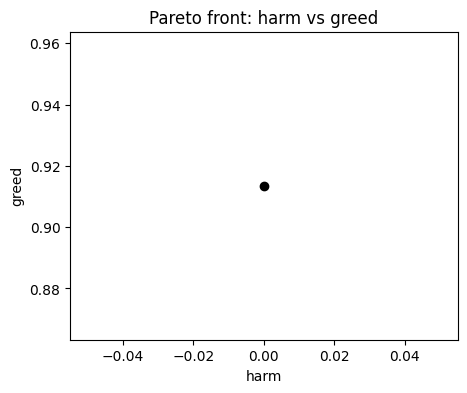

In [ ]:
weights = np.linspace(0, 1, 10)
for w1 in weights:
    w2 = 1 - w1
    env = CombineWrapper(FearWrapper(Convert2DStateWrapper(mo_gym.make("resource-gathering-v0"))), np.array([w1, w2]))
    # env = gym.wrappers.TransformReward(env, combine_rewards)

    ref_point = np.array([-1, 0])
    eval_env = CombineWrapper(FearWrapper(Convert2DStateWrapper(mo_gym.make("resource-gathering-v0"))), np.array([w1, w2]))

    TOTAL_TIMESTEPS = 1e5

    agent = PQL(
        env=env,
        ref_point=ref_point,
        gamma=0.99,
        initial_epsilon=1.0,
        epsilon_decay_steps=TOTAL_TIMESTEPS,
        final_epsilon=0.05,
        seed=42,
        log=True,
    )

    print(f"Starting training ({TOTAL_TIMESTEPS} timesteps)...")
    pareto_front = agent.train(
        total_timesteps=TOTAL_TIMESTEPS,
        eval_env=eval_env,
        ref_point=ref_point,
        log_every=TOTAL_TIMESTEPS / 10,
        action_eval="hypervolume",
    )
    # wandb.log({"no_diamond_reward": True})

    visualize_front_general(pareto_front, columns=["harm", "greed"] )


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Starting training (100000.0 timesteps)...


fairness_pf/cardinality,▁▁▁▁▁▁▁▁▁▁
global_step,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇█████
safety_pf/cardinality,▁▁▁▁▁▁▁▁▁▁
value_pf/cardinality,▁▁▁▁▁▁▁▁▁▁
fairness_pf/cardinality,2
global_step,100000
safety_pf/cardinality,1
value_pf/cardinality,1


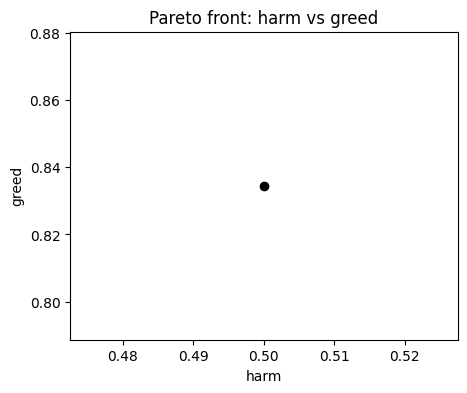

In [9]:
from agent.ecc_pql import ECCPQL


env = FearWrapper(Convert2DStateWrapper(mo_gym.make("resource-gathering-v0")))
# env = gym.wrappers.TransformReward(env, combine_rewards)

safety_ref_point = np.array([-1, -0.5])
fairness_ref_point = np.array([0, 0])
eval_env = FearWrapper(Convert2DStateWrapper(mo_gym.make("resource-gathering-v0")))

TOTAL_TIMESTEPS = 1e5

        # env,
        # safety_ref_point: np.ndarray,
        # fairness_ref_point: np.ndarray,
        # gamma: float = 0.8,
        # initial_epsilon: float = 1.0,
        # epsilon_decay_steps: int = 100000,
        # final_epsilon: float = 0.1,
        # seed: Optional[int] = None,
        # project_name: str = "ECC-MORL",
        # experiment_name: str = "ECC-Pareto Q-Learning",
        # wandb_entity: Optional[str] = None,
        # log: bool = True,
agent = ECCPQL(
    env=env,
    safety_ref_point=safety_ref_point,
    fairness_ref_point=fairness_ref_point,
    gamma=0.99,
    initial_epsilon=1.0,
    epsilon_decay_steps=TOTAL_TIMESTEPS,
    final_epsilon=0.05,
    seed=42,
    log=True,
)

print(f"Starting training ({TOTAL_TIMESTEPS} timesteps)...")
pareto_front = agent.train(
    total_timesteps=TOTAL_TIMESTEPS,
    eval_env=eval_env,
    safety_ref_point=safety_ref_point,
    fairness_ref_point=fairness_ref_point,
    log_every=TOTAL_TIMESTEPS / 10,
    action_eval="hypervolume",
)

visualize_front_general(pareto_front, columns=['harm', 'greed'])

wandb.finish()


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kristofs (kristofs-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


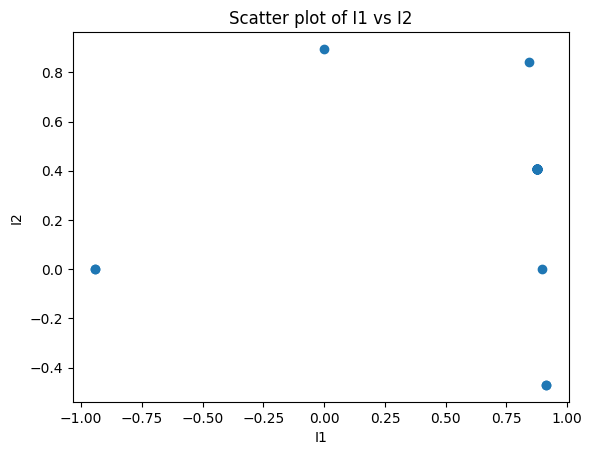

In [4]:
weights = np.linspace(0.0, 1.0, 21)

# 1) train in objective space (no CombineWrapper)
env = FearWrapper(Convert2DStateWrapper(mo_gym.make("resource-gathering-v0")))
eval_env = FearWrapper(Convert2DStateWrapper(mo_gym.make("resource-gathering-v0")))

agent = PQL(env=env, ref_point=np.array([-1, -0.5, 0, 0]), gamma=0.99, log=True, seed=42)
agent.train(total_timesteps=int(1e6), eval_env=eval_env, action_eval="hypervolume")

# 2) evaluate all learned policies in original objective space
obj_returns = np.array(agent._eval_all_policies(eval_env))  # shape [n_policies, 4]
# expected order after FearWrapper: [death, fear, gold, diamond]

death   = obj_returns[:, 0]
fear    = obj_returns[:, 1]
gold    = obj_returns[:, 2]
diamond = obj_returns[:, 3]

I1 = gold + death
I2 = fear + diamond

# 3) weight sweep in interpretation space
rows = []
for w in weights:
    U = w * I1 + (1.0 - w) * I2
    k = int(np.argmax(U))
    rows.append({
        "w": float(w),
        "I1_gold_plus_death": float(I1[k]),
        "I2_fear_plus_diamond": float(I2[k]),
        "utility": float(U[k]),
        "policy_idx": k,
    })

# scatterplot of I1 vs I2
plt.scatter(I1, I2)
plt.xlabel("I1")
plt.ylabel("I2")
plt.title("Scatter plot of I1 vs I2")
plt.show()


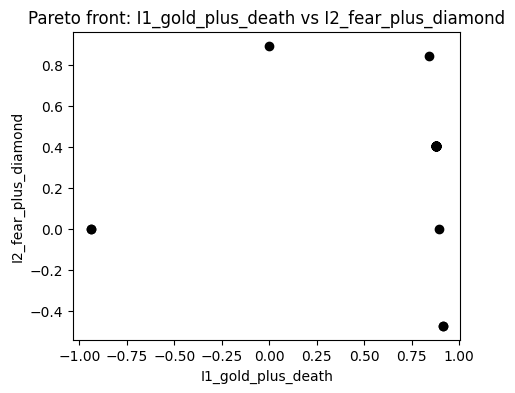

eval/cardinality,5
eval/eum,0.42585
eval/hypervolume,0.35702
global_step,1000000


In [15]:
with wandb.init(project='MORL-Baselines', id='o4ngej47', resume="must") as run:
    visualize_front_general(np.column_stack((I1, I2)), columns=["I1_gold_plus_death", "I2_fear_plus_diamond"])